# Fragility Analysis on MDOF System

## Introduction

This Jupyter Notebook provides a structured workflow for performing a nonlinear time-history analyses (NLTHA), namely cloud analysis on multi-degree-of-freedom (MDOF) structural models using natural unscaled ground-motion records. By combining functions for MDOF calibration, modeling and dynamic analysis, the notebook enables the setup, execution, and post-processing of structural responses under earthquake loading.

The main goals of this notebook:

1. **Calibrate MDOF models based on single-degree-of-freedom (SDOF) oscillator capacity**: Calibrate storey-based force-deformation relationships using SDOF capacity curve definition (spectral displacement-spectral acceleration) based on the methodology of Lu et al. (2020) and other modifications to account for distinct response typologies (i.e., bilinear, trilinear and quadrilinear backbone definitions)

2. **Compile and construct MDOF Models in OpenSees**: Define and assemble MDOF models by specifying essential structural properties, including mass, heights, fundamental period and nonlinear response characteristics at each degree of freedom

3. **Run Nonlinear Time-History Analysis (NLTHA) in OpenSees**: Simulate the dynamic response of MDOF structures under time-dependent inputs, such as ground motion records, to realistically assess structural behavior and response metrics (e.g., peak storey drifts, peak floor accelerations) under loading conditions and extract critical response metrics and model information.

4. **Fragility Analysis**: Postprocess cloud analysis results to fit a probabilistic seismic demand model (PSDM) to ultimately estimate the median seismic intensities and total dispersion associated with arbitrary demand-based thresholds (i.e., maximum interstorey drift-based) and construct the fragility functions relating damage state exceedance probabilities with increasing levels of ground-shaking.

5. **Vulnerability Analysis**: Integrate fragility functions with consequence models (i.e., damage-to-loss models) to determine the continuous relationship between a decision variable and increasing levels of ground-shaking.


The notebook provides a step-by-step guide, covering each phase from MDOF model calibration, setup to input parameter configuration, analysis execution, and detailed results extraction and postprocessing. Users should have some familiarity with python scripts, structural dynamics, computational modeling, and performance-based earthquake engineering to fully benefit from this material.

---

## References

[1] Jalayer F, Ebrahimian H, Miano A, Manfredi G, Sezen H. Analytical fragility assessment using unscaled ground motion records. Earthquake Engng Struct Dyn. 2017; 46: 2639–2663. https://doi.org/10.1002/eqe.2922

[2] Lu X, McKenna F, Cheng Q, Xu Z, Zeng X, Mahin SA. An open-source framework for regional earthquake loss estimation using the city-scale nonlinear time history analysis. Earthquake Spectra. 2020;36(2):806-831. doi:10.1177/8755293019891724

[3] Lallemant, D., Kiremidjian, A., and Burton, H. (2015), Statistical procedures for developing earthquake damage fragility curves. Earthquake Engng Struct. Dyn., 44, 1373–1389. doi: 10.1002/eqe.2522.

## Initialize Libraries ##

In [1]:
import os
import sys
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import the classes necessary for structural analysis
from openquake.vmtk.postprocessor import postprocessor                  # oq-vtmk postprocessing class
from openquake.vmtk.plotter       import plotter                        # oq-vmtk plotting class
from openquake.vmtk.utilities     import import_from_pkl, export_to_pkl # oq-vmtk utility class

## Import Pre-Computed Analysis Data ##

In [2]:
# Define the directory of the ground-motion and cloud analysis dictionaries
input_directory  = './in'            

# Import the intensity measure dictionary 
ims  = import_from_pkl(os.path.join(input_directory, 'imls_esrm20.pkl'))  

# Import the analysis dictionary
ansys_dict = import_from_pkl(os.path.join(input_directory, 'ansys_out.pkl'))  

## Define Modified Cloud Analysis Probabilistic Seismic Demand Model Parameters ##

In [3]:
# Intensity measures to use for postprocessing cloud analyses
IMTs      = 'PGA'

# Damage thresholds (maximum peak storey drift values in rad)
damage_thresholds    =  [0.00150, 0.00545, 0.00952, 0.0135] 

# The lower limit to be applied for censoring edp values (below 0.1 the minimum threshold for slight damage is considered a negligible case)
lower_limit = 0.1*damage_thresholds[0]

# The upper limit to be applied for consoring edp values (above 1.5 the maximum threshold is considered a collapse case) 
censored_limit = 1.5*damage_thresholds[-1]   

## Fragility Function Methods: A Comparative Overview

Fragility functions express the probability that a structure exceeds a given
damage state (DS) as a function of an Intensity Measure (IM), such as PGA.
All methods below share the same input data (IMLs, EDPs, and damage thresholds)
but differ in **how they model the relationship between demand and capacity**
and **how uncertainty is treated**.

## Method 1 — Lognormal CDF (Baseline, Only Record-to-Record Uncertainty)

This is the **classical cloud analysis fragility**. A power-law regression is
fitted in log-space between the IM and EDP:

$$\ln(\text{EDP}) = b_0 + b_1 \ln(\text{IM}) + \varepsilon, \quad \varepsilon \sim \mathcal{N}(0, \sigma_{record-to-record}^2)$$

The dispersion $\beta$ driving the shape of the lognormal CDF equals the
regression residual standard deviation alone (i.e., the uncertainty associated with the record-to-record variability):

$$\beta = \sigma_{record-to-record}$$

The fragility function itself is then expressed as:

$$P(DS \geq ds \mid IM) = \Phi\!\left(\frac{\ln(\text{IM}) - \ln(\theta)}{\beta}\right)$$

where $\theta$ is the median IM capacity (derived from the regression) and
$\Phi(\cdot)$ is the standard normal CDF.

**Implication:** This is the narrowest, most optimistic fragility curve set.
It assumes the fitted model perfectly represents every building of this class,
and that the damage thresholds are known exactly. Use this only as a
deterministic reference benchmark.

## Method 2 — Lognormal CDF with Record-to-Record and Building-to-Building Uncertainty ($\sigma_{building-to-building}$)

An additional aleatory uncertainty term $\sigma_{building-to-building}$ is introduced to
account for the fact that real buildings of the same class vary in their
construction quality, geometry, and material properties. The total dispersion
becomes:

$$\beta_{total} = \sqrt{\sigma_{record-to-record}^2 + \sigma_{building-to-building}^2}$$

**Implication:** The fragility curves become **shallower and wider**. The
probability of exceedance at low IM levels increases (the left tail rises),
while the curve takes longer to approach 1.0 at high IM levels. This is a
more honest representation of a building *class* rather than a single,
perfectly known structure.

## Method 3 — Lognormal CDF with Record-to-Record, Building-to-Building and Damage State Uncertainty ($\sigma_{ds} = 0.3$)

A third uncertainty source is added: the damage thresholds themselves are not
known exactly. Engineering judgement, experimental scatter, and code
interpretation all introduce variability in where a DS boundary truly lies.
This is captured as:

$$\beta_{total} = \sqrt{\sigma_{record-to-record}^2 + \sigma_{building-to-building}^2 + \sigma_{ds}^2}$$

**Implication:** Dispersion increases further, producing even shallower and
more spread-out curves. Crucially, **adjacent damage state curves begin to
overlap more**, reflecting genuine uncertainty about which DS a structure has
entered. 

## Method 4 — Lognormal CDF with Uncertainty and Fragility Rotation (20th Percentile Anchor)

For this example, this method applies the same total dispersion as Method 3, but then **rotates
the fragility curve about its 20th-percentile IM level**. The median $\theta$
is adjusted so that the curve still passes through the same point at
$P(DS \geq ds | IM) = 0.20$, while the increased $\beta$ is redistributed
above that anchor:

$$\theta_{rotated} = \text{IM}_{P=0.20} \cdot \exp\!\left(-\beta_{total} \cdot \Phi^{-1}(0.20)\right)$$

**Implication:** Rotation prevents the additional uncertainty from artificially
inflating failure probabilities at low IM levels (a common and conservative
artefact of simply adding dispersion). The lower tail is anchored to the
empirical data, making this approach better suited to **loss calculations** where
overestimation of damage at low shaking intensities would bias expected annual
losses upward.

## Method 5 — Generalised Linear Model with Logit Link

Rather than assuming lognormality of the EDP, this method frames exceedance
as a **binary classification problem**. For each record, the EDP either
exceeds the threshold or it does not. A logistic (logit-link) GLM is then
fitted directly to those binary outcomes:

$$\ln\!\frac{P}{1-P} = \alpha_0 + \alpha_1 \ln(\text{IM})$$

$$P(DS \geq ds \mid IM) = \frac{1}{1 + e^{-(\alpha_0 + \alpha_1 \ln IM)}}$$

**Implication:** The logit model is **distribution-free** with respect to the
EDP — it does not assume the demand is lognormally distributed. It is more
robust when the demand-capacity relationship is non-linear or when the dataset
contains a mix of collapse and non-collapse records. The resulting curve shape
is still sigmoidal but fitted to actual exceedance counts rather than to a
regression residual.

## Method 6 — Generalised Linear Model with Probit Link

The probit model is structurally identical to the logit approach but replaces
the logistic sigmoid with the **standard normal CDF** as the link function:

$$P(DS \geq ds \mid IM) = \Phi(\alpha_0 + \alpha_1 \ln IM)$$

This is mathematically equivalent to fitting a lognormal CDF to binary
exceedance data via maximum likelihood, rather than through regression residuals.

**Implication:** In practice the logit and probit curves are nearly
indistinguishable for probabilities between ~5 % and ~95 %. The probit tail
behaviour is slightly lighter (faster approach to 0 and 1), making it
marginally less conservative at extremes. The probit is the **theoretically
consistent** choice if you believe exceedance probability is governed by a
normally distributed latent demand variable.


## Method 7 — Continuous Link Model (Ordinal / CLM)

The Continuous Link Model (CLM) — also called an ordinal regression or
proportional-odds model — treats damage as an **ordered categorical variable**
(DS0 < DS1 < DS2 < ...) and fits all damage state thresholds simultaneously in
a single model. It enforces the logical constraint that fragility curves cannot
cross:

$$P(DS \geq ds_k \mid IM) = \Phi(\alpha_k + \beta \ln IM), \quad \alpha_1 < \alpha_2 < \alpha_3 < \ldots$$

The shared slope $\beta$ (the proportional-odds assumption) means every DS
curve has the same IM sensitivity; only the threshold intercepts $\alpha_k$ differ.

**Implication:** By fitting all damage states jointly, the CLM is
**statistically more efficient** — it uses every observation to inform every
curve simultaneously. It is the most rigorous method when the ordered nature of
damage matters and when the dataset is limited. The non-crossing guarantee is a
significant practical advantage over independently fitted curves, which can
produce physically implausible intersections at the tails.

---

## Summary: Effect of Increasing Uncertainty on $\beta_{total}$

| Method | $\sigma_{b2b}$ | $\sigma_{ds}$ | $\beta_{total}$ | Curve shape |
|--------|:--------------:|:-------------:|:----------------:|-------------|
| 1 | 0.0 | 0.0 | $\sigma_{reg}$ | Steepest, narrowest |
| 2 | 0.3 | 0.0 | $\sqrt{\sigma_{reg}^2 + 0.09}$ | Shallower |
| 3 | 0.3 | 0.3 | $\sqrt{\sigma_{reg}^2 + 0.18}$ | Shallower still, curves overlap more |
| 4 | 0.3 | 0.3 | Same as 3, but anchored | Lower tail corrected |
| 5–7 | — | — | MLE-fitted | Data-driven, no EDP distribution assumed |

As $\beta_{total}$ grows, the fragility curve rotates **clockwise about its
median**: the left tail rises (more damage predicted at low IM) and the right
tail flattens (slower saturation at high IM). For loss calculations, this
translates directly into higher expected annual losses — so the choice of
uncertainty budget is not merely academic.

In [6]:
# Initialise the postprocessor class
pp = postprocessor()
    
# Import the current intensity measure type
imls = ims['PGA']

# Import the engineering demand parameters (i.e., mpsd) from the analysis dictionary (processed from example 2)
edps = ansys_dict['max_peak_drift_list']  

# Process cloud analysis results using the "do_modified_cloud_analysis" function called from "postprocessor" 
# The output will be automatically stored in a dictionary

# Fragility Method 1: Lognormal CDF considering no additional modelling uncertainty or damage state threshold uncertainty
cloud_dict_frag_1 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  sigma_build2build=0.0,
                                                  sigma_ds = 0.0,
                                                  fragility_method = 'lognormal')

# Fragility Method 2: Lognormal CDF considering an additional modelling uncertainty of 0.3 and no damage state threshold uncertainty
cloud_dict_frag_2 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  sigma_build2build=0.3,
                                                  sigma_ds = 0.0,
                                                  fragility_method = 'lognormal')

# Fragility Method 3: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 
cloud_dict_frag_3 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  sigma_build2build=0.3,
                                                  sigma_ds = 0.3,
                                                  fragility_method = 'lognormal')

# Fragility Method 4: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 and fragility rotation about the 20th percentile
cloud_dict_frag_4 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  sigma_build2build=0.3,
                                                  sigma_ds = 0.3,
                                                  fragility_rotation = True,
                                                  rotation_percentile = 0.20,
                                                  fragility_method = 'lognormal')

# Fragility Method 5: Generalised Linear Model (GLM) using a logit link function
cloud_dict_frag_5 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  fragility_method = 'logit')

# Fragility Method 6: Generalised Linear Model (GLM) using a probit function
cloud_dict_frag_6 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  fragility_method = 'probit')

# Fragility Method 7: Continuous link model (CLM) or ordinal
cloud_dict_frag_7 = pp.do_modified_cloud_analysis(imls,
                                                  edps,
                                                  damage_thresholds,
                                                  lower_limit,
                                                  censored_limit,
                                                  fragility_method = 'ordinal')

## Explore Fragility Function Models ##

[0.2107597  0.52705364 0.69075762 0.78039305 0.96070077]


(0.0, 1.0)

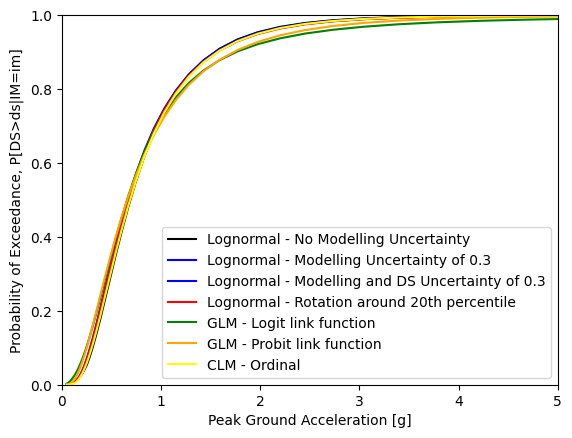

In [7]:
# Fragility function parameters can be easily retrieved from the output of the pp.do_cloud_analysis() method
# by calling the dictionary key 'fragility' (e.g., output['fragility']).
# where all outputs associated with fragility analysis are stored including the median and dispersions associated with each damage state,
# the sampled intensity measure levels and the probabilities of exceedance for each damage state.
# Example:
print(cloud_dict_frag_1['fragility']['medians']) # this will print out the median seismic intensities (in g) required to attain each demand-based damage state

# Visualise the different fragility analysis methods assumptions on the end result (i.e., probabilities of exceedance)

# Fragility Method 1: Lognormal CDF considering no additional modelling uncertainty or damage state threshold uncertainty
plt.plot(cloud_dict_frag_1['fragility']['intensities'], cloud_dict_frag_1['fragility']['poes'][:,2], color = 'black', 
         label = 'Lognormal - No Modelling Uncertainty') 

# Fragility Method 2: Lognormal CDF considering an additional modelling uncertainty of 0.3 and no damage state threshold uncertainty
plt.plot(cloud_dict_frag_2['fragility']['intensities'], cloud_dict_frag_2['fragility']['poes'][:,2], color = 'blue', 
         label = 'Lognormal - Modelling Uncertainty of 0.3') 

# Fragility Method 3: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 
plt.plot(cloud_dict_frag_3['fragility']['intensities'], cloud_dict_frag_3['fragility']['poes'][:,2], color = 'blue', 
         label = 'Lognormal - Modelling and DS Uncertainty of 0.3') 

# Fragility Method 4: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 and fragility rotation about the 20th percentile
plt.plot(cloud_dict_frag_4['fragility']['intensities'], cloud_dict_frag_4['fragility']['poes'][:,2], color = 'red', 
         label = 'Lognormal - Rotation around 20th percentile') 

# Fragility Method 5: Generalised Linear Model (GLM) using a logit link function
plt.plot(cloud_dict_frag_5['fragility']['intensities'], cloud_dict_frag_5['fragility']['poes'][:,2], color = 'green', 
         label = 'GLM - Logit link function') 

# Fragility Method 5: Generalised Linear Model (GLM) using a probit function
plt.plot(cloud_dict_frag_6['fragility']['intensities'], cloud_dict_frag_6['fragility']['poes'][:,2], color = 'orange', 
         label = 'GLM - Probit link function') 

# Fragility Method 7: Continuous link model (CLM) or ordinal
plt.plot(cloud_dict_frag_7['fragility']['intensities'], cloud_dict_frag_7['fragility']['poes'][:,2], color = 'yellow', 
         label = 'CLM - Ordinal') 

plt.legend()
plt.xlabel('Peak Ground Acceleration [g]')
plt.ylabel('Probability of Exceedance, P[DS>ds|IM=im]')
plt.xlim([0,5])
plt.ylim([0,1])


## Implication of Fragility Function Methods on Loss Models ## 

In [8]:
# Define consequence model to relate structural damage to a decision variable (i.e., expected loss ratio) 
consequence_model = [0.05, 0.20, 0.60, 1.00] # damage-to-loss ratios

# Define the uncertainty associated with each damage-to-loss ratio via coefficients of variation
consequence_cov = [0.30, 0.25, 0.20, 0.00] 

# Fragility Method 1: Lognormal CDF considering no additional modelling uncertainty or damage state threshold uncertainty
structural_vulnerability_method_1 = pp.calculate_vulnerability_function(cloud_dict_frag_1['fragility']['poes'][:,:4],  # Use the poes output (columns 1 to 4 > DS1 to DS4)
                                                                        consequence_model,                             # The consequence model representing the normalised loss ratios per damage state
                                                                        cov_consequence = consequence_cov,             # The coefficient of variation model representing the uncertainty around the loss ratios per damage state
                                                                        uncertainty=True)                              # Set uncertainty equal to False to not calculate COV of the Beta Distribution (not required for this demonstration)

# Fragility Method 2: Lognormal CDF considering an additional modelling uncertainty of 0.3 and no damage state threshold uncertainty
structural_vulnerability_method_2 = pp.calculate_vulnerability_function(cloud_dict_frag_2['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                

# Fragility Method 3: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 
structural_vulnerability_method_3 = pp.calculate_vulnerability_function(cloud_dict_frag_3['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                

# Fragility Method 4: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 and fragility rotation about the 20th percentile
structural_vulnerability_method_4 = pp.calculate_vulnerability_function(cloud_dict_frag_4['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                

# Fragility Method 5: Generalised Linear Model (GLM) using a logit link function
structural_vulnerability_method_5 = pp.calculate_vulnerability_function(cloud_dict_frag_5['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                

# Fragility Method 6: Generalised Linear Model (GLM) using a probit function
structural_vulnerability_method_6 = pp.calculate_vulnerability_function(cloud_dict_frag_6['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                

# Fragility Method 7: Continuous link model (CLM) or ordinal
structural_vulnerability_method_7 = pp.calculate_vulnerability_function(cloud_dict_frag_7['fragility']['poes'][:,:4], 
                                                                        consequence_model,                             
                                                                        cov_consequence = consequence_cov,            
                                                                        uncertainty=False)                                


(0.0, 1.0)

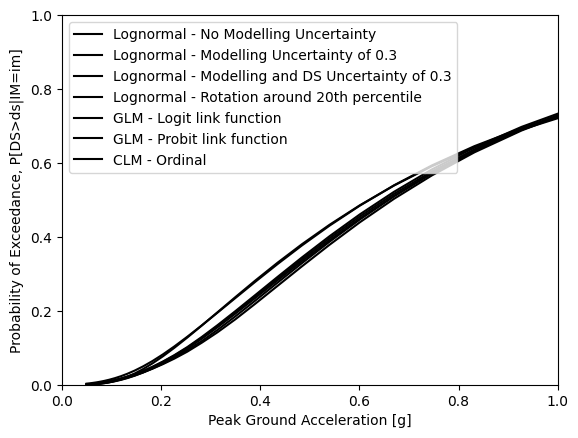

In [11]:
# Fragility Method 1: Lognormal CDF considering no additional modelling uncertainty or damage state threshold uncertainty
plt.plot(structural_vulnerability_method_1['IML'], structural_vulnerability_method_1['Loss'], color = 'black', 
         label = 'Lognormal - No Modelling Uncertainty') 

# Fragility Method 2: Lognormal CDF considering an additional modelling uncertainty of 0.3 and no damage state threshold uncertainty
plt.plot(structural_vulnerability_method_2['IML'], structural_vulnerability_method_2['Loss'], color = 'black', 
         label = 'Lognormal - Modelling Uncertainty of 0.3') 

# Fragility Method 3: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 
plt.plot(structural_vulnerability_method_3['IML'], structural_vulnerability_method_3['Loss'], color = 'black', 
         label = 'Lognormal - Modelling and DS Uncertainty of 0.3') 

# Fragility Method 4: Lognormal CDF considering an additional modelling and damage state uncertainties of 0.3 and fragility rotation about the 20th percentile
plt.plot(structural_vulnerability_method_4['IML'], structural_vulnerability_method_4['Loss'], color = 'black', 
         label = 'Lognormal - Rotation around 20th percentile') 

# Fragility Method 5: Generalised Linear Model (GLM) using a logit link function
plt.plot(structural_vulnerability_method_5['IML'], structural_vulnerability_method_5['Loss'], color = 'black', 
         label = 'GLM - Logit link function') 

# Fragility Method 5: Generalised Linear Model (GLM) using a probit function
plt.plot(structural_vulnerability_method_6['IML'], structural_vulnerability_method_6['Loss'], color = 'black', 
         label = 'GLM - Probit link function') 

# Fragility Method 7: Continuous link model (CLM) or ordinal
plt.plot(structural_vulnerability_method_7['IML'], structural_vulnerability_method_7['Loss'], color = 'black', 
         label = 'CLM - Ordinal') 

plt.legend()
plt.xlabel('Peak Ground Acceleration [g]')
plt.ylabel('Probability of Exceedance, P[DS>ds|IM=im]')
plt.xlim([0,1])
plt.ylim([0,1])

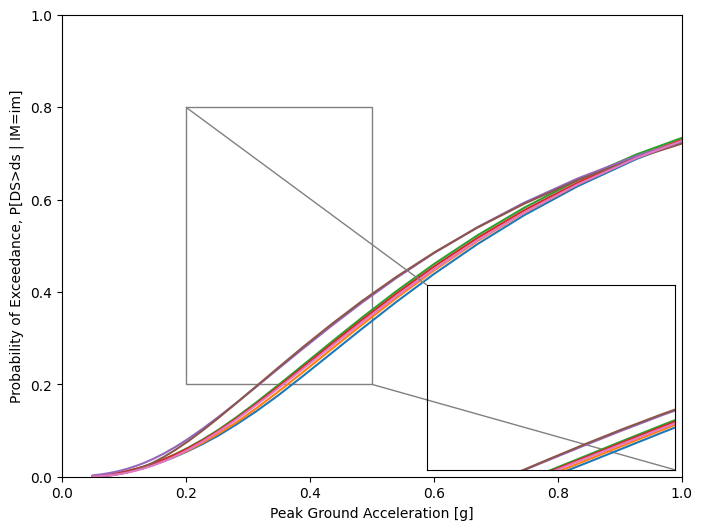

In [13]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, ax = plt.subplots(figsize=(8,6))

# ---- Main plot ----
ax.plot(structural_vulnerability_method_1['IML'], structural_vulnerability_method_1['Loss'], label='Method 1')
ax.plot(structural_vulnerability_method_2['IML'], structural_vulnerability_method_2['Loss'], label='Method 2')
ax.plot(structural_vulnerability_method_3['IML'], structural_vulnerability_method_3['Loss'], label='Method 3')
ax.plot(structural_vulnerability_method_4['IML'], structural_vulnerability_method_4['Loss'], label='Method 4')
ax.plot(structural_vulnerability_method_5['IML'], structural_vulnerability_method_5['Loss'], label='GLM Logit')
ax.plot(structural_vulnerability_method_6['IML'], structural_vulnerability_method_6['Loss'], label='GLM Probit')
ax.plot(structural_vulnerability_method_7['IML'], structural_vulnerability_method_7['Loss'], label='CLM Ordinal')

ax.set_xlabel('Peak Ground Acceleration [g]')
ax.set_ylabel('Probability of Exceedance, P[DS>ds | IM=im]')
ax.set_xlim(0,1)
ax.set_ylim(0,1)
ax.legend()

# ---- Zoom inset ----
axins = inset_axes(ax, width="40%", height="40%", loc='lower right')

axins.plot(structural_vulnerability_method_1['IML'], structural_vulnerability_method_1['Loss'])
axins.plot(structural_vulnerability_method_2['IML'], structural_vulnerability_method_2['Loss'])
axins.plot(structural_vulnerability_method_3['IML'], structural_vulnerability_method_3['Loss'])
axins.plot(structural_vulnerability_method_4['IML'], structural_vulnerability_method_4['Loss'])
axins.plot(structural_vulnerability_method_5['IML'], structural_vulnerability_method_5['Loss'])
axins.plot(structural_vulnerability_method_6['IML'], structural_vulnerability_method_6['Loss'])
axins.plot(structural_vulnerability_method_7['IML'], structural_vulnerability_method_7['Loss'])

# ---- Define zoom region ----
x1, x2 = 0.2, 0.5
y1, y2 = 0.2, 0.8
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Remove tick labels for cleaner look
axins.set_xticks([])
axins.set_yticks([])

# Draw box on main plot to indicate zoom area
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()